# Данные


### Импорт библиотек

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

### Загрузка данных

In [ ]:
df = pd.read_csv('machine_temperature_system_failure.csv', parse_dates=['timestamp'])
df = df.sort_values('timestamp').reset_index(drop=True)

### Визуализация временного ряда

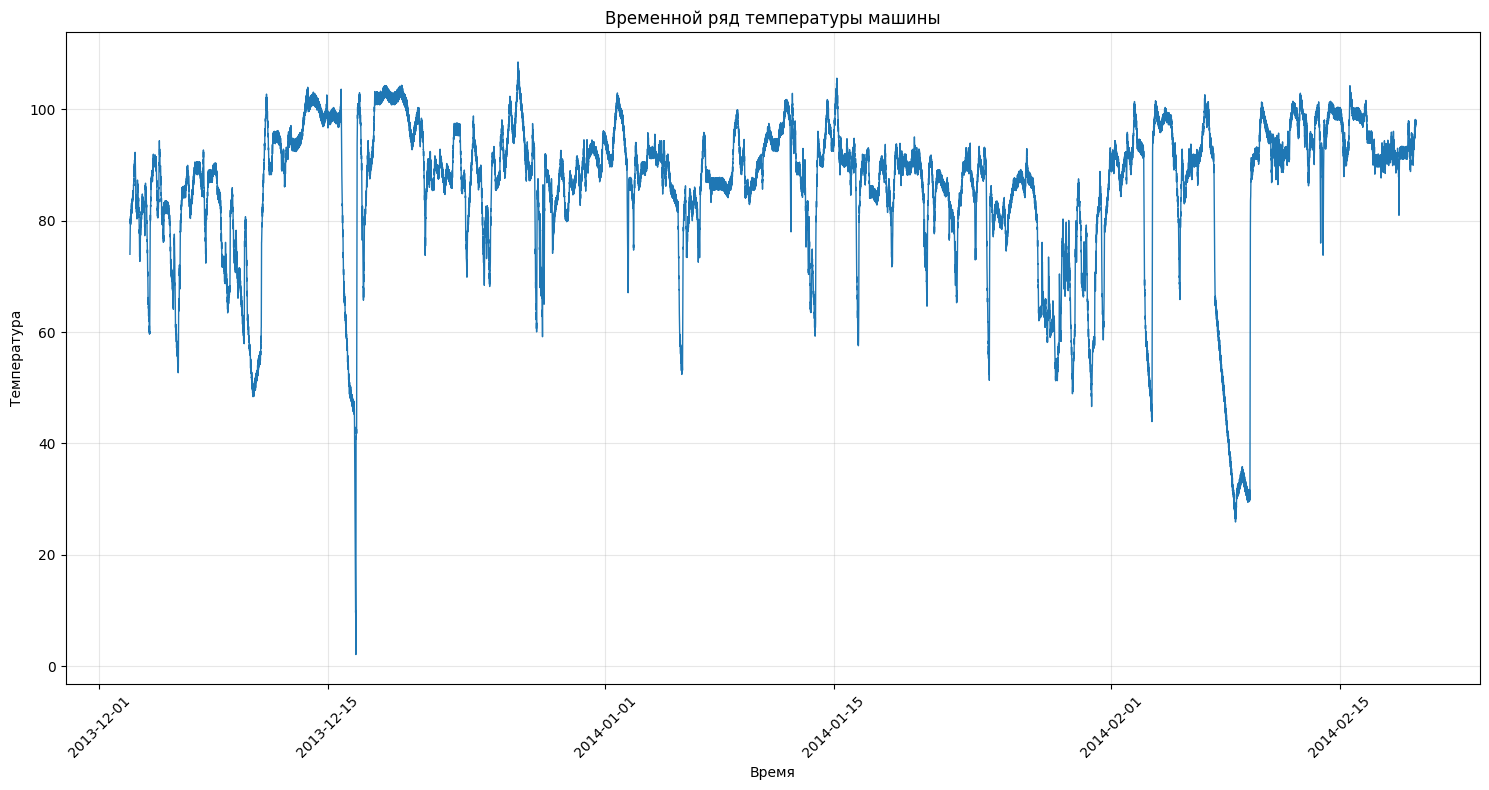

In [ ]:
plt.figure(figsize=(15, 8))
plt.plot(df['timestamp'], df['value'], linewidth=1)
plt.title('Временной ряд температуры машины')
plt.xlabel('Время')
plt.ylabel('Температура')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

На основе визуализации видим, что:
                              
*   Тренд: нисходящий к концу каждого периода
*   Сезонность: колебания в 10-20 градусов
*   Стационарность: ряд не стационарен (тк тренд нисходящий, непостоянная амплитуда колебаний, влияние сезонных паттернов)




                          

### Разделение на Train/Test

In [ ]:
# Удалим последнюю строку с пропущенным значением
df = df.dropna()

train_size = int(len(df) * 0.8)
train_data = df.iloc[:train_size]
test_data = df.iloc[train_size:]

print(f"Общий размер датасета: {len(df)}")
print(f"Обучающая выборка: {len(train_data)} записей")
print(f"Тестовая выборка: {len(test_data)} записей")
print(f"Период обучающей выборки: {train_data['timestamp'].min()} - {train_data['timestamp'].max()}")
print(f"Период тестовой выборки: {test_data['timestamp'].min()} - {test_data['timestamp'].max()}")

Общий размер датасета: 22695
Обучающая выборка: 18156 записей
Тестовая выборка: 4539 записей
Период обучающей выборки: 2013-12-02 21:15:00 - 2014-02-03 21:10:00
Период тестовой выборки: 2014-02-03 21:15:00 - 2014-02-19 15:25:00


### Выбор метрики и оценка качетства

В качетве метрики выберем MAE (Mean Absolute Error) - средняя абсолютная ошибк

# Прогнозирование

## Бейзлайн

### Наивный прогноз

In [ ]:
def naive_forecast(train, test):
    last_value = train['value'].iloc[-1]
    predictions = [last_value] * len(test)
    return predictions

naive_predictions = naive_forecast(train_data, test_data)
test_data = test_data.copy()
test_data['naive_prediction'] = naive_predictions

print(f"Последнее значение из train: {train_data['value'].iloc[-1]:.2f}°C")
print(f"Первое значение в test: {test_data['value'].iloc[0]:.2f}°C")

Последнее значение из train: 98.05°C
Первое значение в test: 98.74°C


### Визуализация результата работы модели

(array([16040., 16054., 16071., 16085., 16102., 16116.]),
 [Text(16040.0, 0, '2013-12-01'),
  Text(16054.0, 0, '2013-12-15'),
  Text(16071.0, 0, '2014-01-01'),
  Text(16085.0, 0, '2014-01-15'),
  Text(16102.0, 0, '2014-02-01'),
  Text(16116.0, 0, '2014-02-15')])

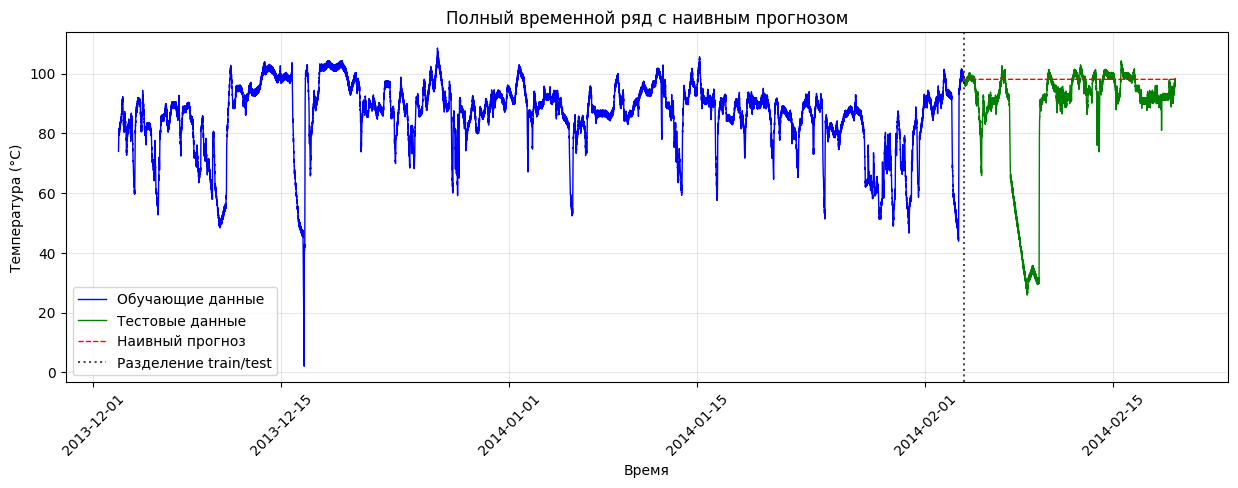

In [ ]:
plt.figure(figsize=(15, 10))

plt.subplot(2, 1, 1)
plt.plot(train_data['timestamp'], train_data['value'], label='Обучающие данные', color='blue', linewidth=1)
plt.plot(test_data['timestamp'], test_data['value'], label='Тестовые данные', color='green', linewidth=1)
plt.plot(test_data['timestamp'], test_data['naive_prediction'], label='Наивный прогноз', color='red', linestyle='--', linewidth=1)
plt.axvline(x=train_data['timestamp'].iloc[-1], color='black', linestyle=':', alpha=0.7, label='Разделение train/test')
plt.title('Полный временной ряд с наивным прогнозом')
plt.xlabel('Время')
plt.ylabel('Температура (°C)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

### Вычисление метрики MAE и замеры качества

In [ ]:
def calculate_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)

    return {
        'MAE': round(mae, 4)
    }

metrics = calculate_metrics(test_data['value'], test_data['naive_prediction'])

for metric, value in metrics.items():
    if metric == 'MAPE':
        print(f"{metric}: {value}%")
    else:
        print(f"{metric}: {value}°C")

MAE: 12.0013°C


## Статистическая модель

### Тест Дики-Фулера

In [ ]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings('ignore')

def adf_test(timeseries):
    result = adfuller(timeseries, autolag='AIC')

    print(f'ADF Statistic: {result[0]:.6f}')
    print(f'p-value: {result[1]:.6f}')
    print(f'Количество лагов: {result[2]}')
    print(f'Количество наблюдений: {result[3]}')
    print('Критические значения:')
    for key, value in result[4].items():
        print(f'   {key}: {value:.3f}')

    if result[1] <= 0.05:
        print("Ряд СТАЦИОНАРЕН (отвергаем H0)")
    else:
        print("Ряд НЕСТАЦИОНАРЕН (не можем отвергнуть H0)")

    return result

adf_result_original = adf_test(df['value'])

ADF Statistic: -7.369503
p-value: 0.000000
Количество лагов: 20
Количество наблюдений: 22674
Критические значения:
   1%: -3.431
   5%: -2.862
   10%: -2.567
Ряд СТАЦИОНАРЕН (отвергаем H0)


### Построение графиков ACEF/PACF

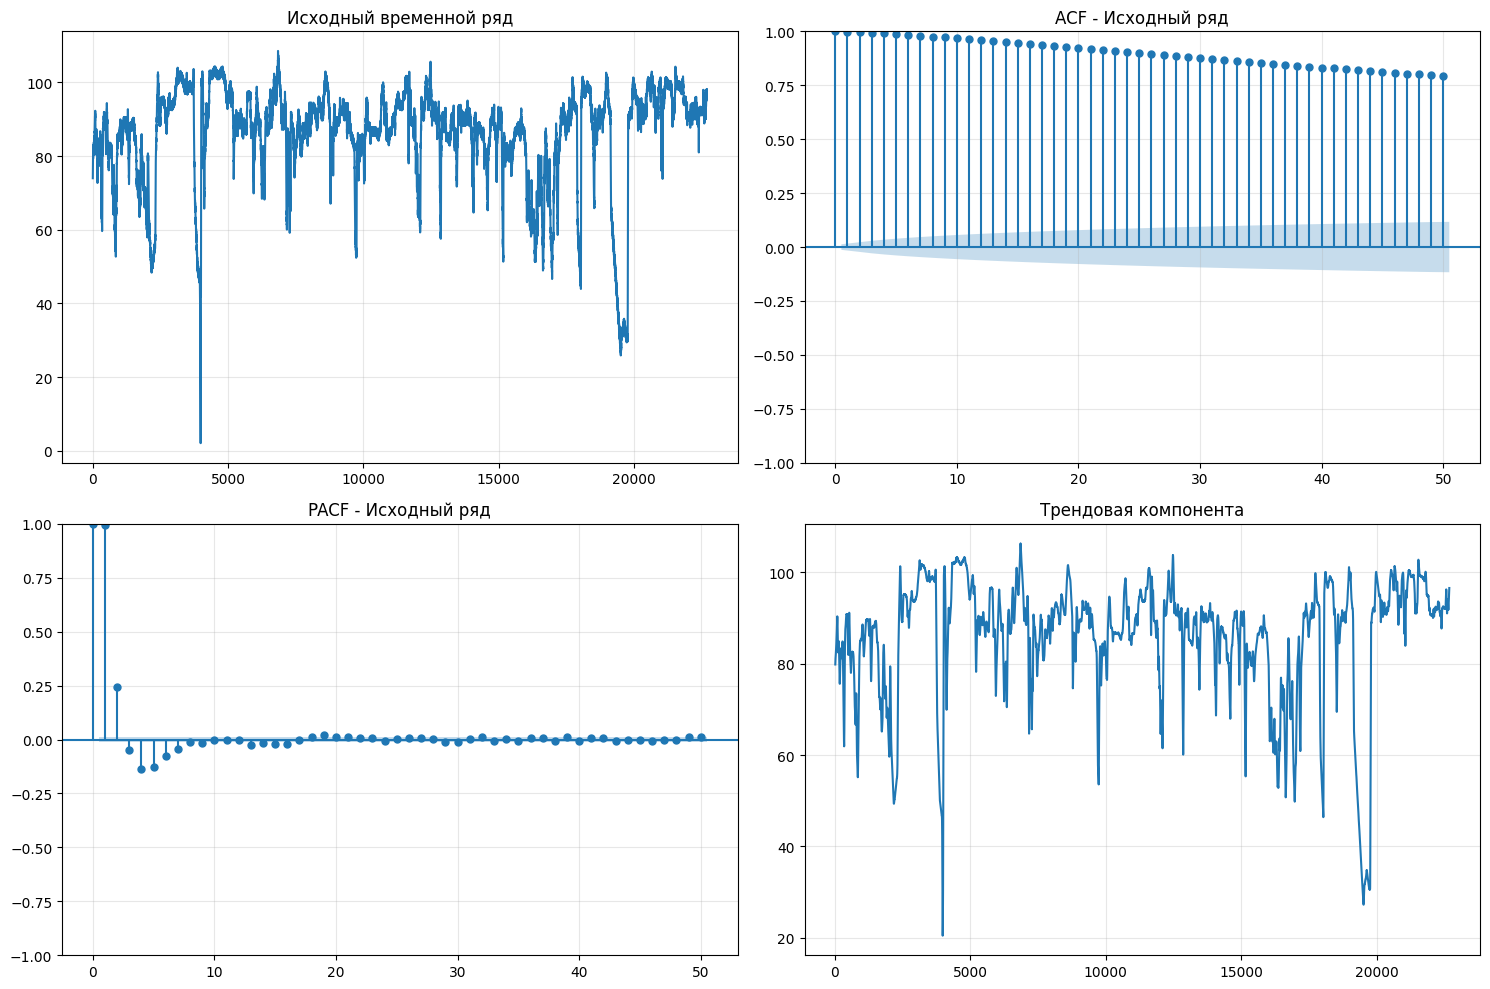

In [ ]:
# Графики ACF и PACF для исходного ряда
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
plt.plot(df['value'])
plt.title('Исходный временной ряд')
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 2)
plot_acf(df['value'], lags=50, ax=plt.gca(), title='ACF - Исходный ряд')
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 3)
plot_pacf(df['value'], lags=50, ax=plt.gca(), title='PACF - Исходный ряд')
plt.grid(True, alpha=0.3)

# Декомпозиция ряда для анализа сезонности
plt.subplot(2, 2, 4)
try:
    decomposition = seasonal_decompose(df['value'], period=24, model='additive')
    decomposition.trend.plot(ax=plt.gca(), title='Трендовая компонента')
    plt.grid(True, alpha=0.3)
except:
    plt.text(0.5, 0.5, 'Декомпозиция не удалась', ha='center', va='center')
    plt.title('Трендовая компонента')

plt.tight_layout()
plt.show()

### Предположение о наличие/отсутвии сезонности

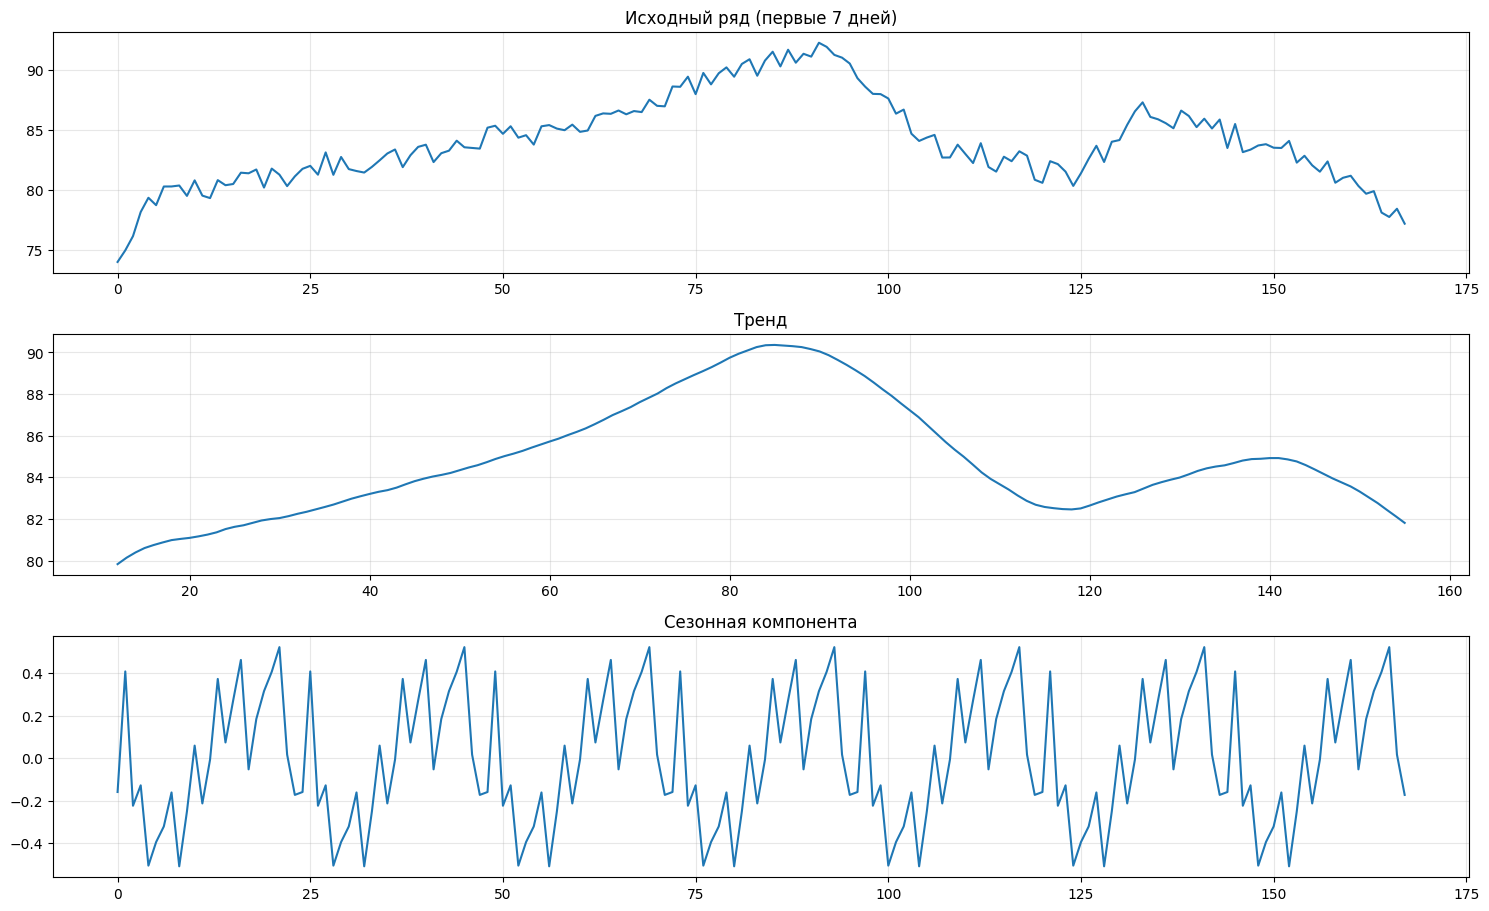

In [ ]:
try:
    plt.figure(figsize=(15, 12))

    decomposition = seasonal_decompose(df['value'][:168], period=24, model='additive')

    plt.subplot(4, 1, 1)
    decomposition.observed.plot(title='Исходный ряд (первые 7 дней)')
    plt.grid(True, alpha=0.3)

    plt.subplot(4, 1, 2)
    decomposition.trend.plot(title='Тренд')
    plt.grid(True, alpha=0.3)

    plt.subplot(4, 1, 3)
    decomposition.seasonal.plot(title='Сезонная компонента')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"Декомпозиция не удалась: {e}")

### Преобразования для придания ряду стационарности

In [ ]:
# Дифференцирование
df_diff = df.copy()
df_diff['value_diff'] = df_diff['value'].diff()

# Удаление NaN после дифференцирования
df_diff = df_diff.dropna()

adf_test(df_diff['value_diff'])

ADF Statistic: -30.314918
p-value: 0.000000
Количество лагов: 21
Количество наблюдений: 22672
Критические значения:
   1%: -3.431
   5%: -2.862
   10%: -2.567
Ряд СТАЦИОНАРЕН (отвергаем H0)


(np.float64(-30.314918012332928),
 0.0,
 21,
 22672,
 {'1%': np.float64(-3.4306384633265323),
  '5%': np.float64(-2.861667491479714),
  '10%': np.float64(-2.566837860087214)},
 np.float64(65131.76262580063))

### Проверка стационарности и визуализация ACF/PACF

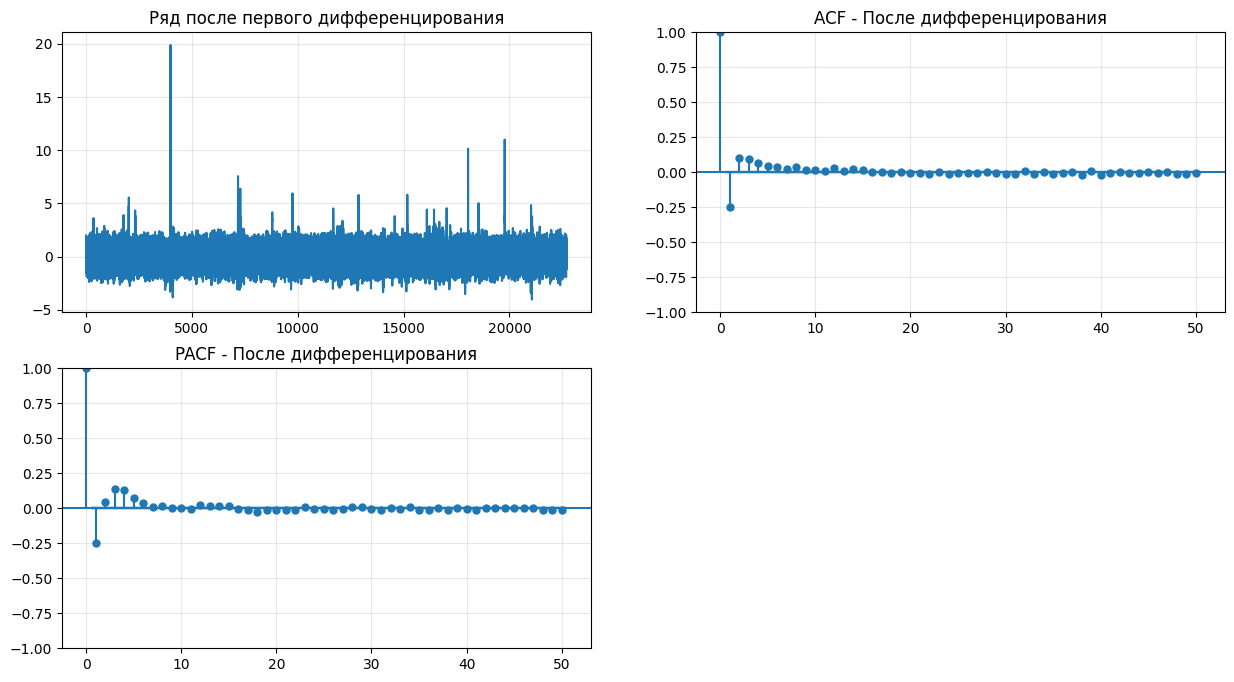

In [ ]:
plt.figure(figsize=(15, 8))

plt.subplot(2, 2, 1)
plt.plot(df_diff['value_diff'])
plt.title('Ряд после первого дифференцирования')
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 2)
plot_acf(df_diff['value_diff'], lags=50, ax=plt.gca(), title='ACF - После дифференцирования')
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 3)
plot_pacf(df_diff['value_diff'], lags=50, ax=plt.gca(), title='PACF - После дифференцирования')
plt.grid(True, alpha=0.3)

После дифференцирования, ряд стал стационарным, так: среднее значение ряда колеблется около нуля (остались только случайные колебания), дисперсия ряда почти постоянна, ACF быстро затухает

### Подбор параметров ARIMA

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from itertools import product

def find_best_arima_params(train_data, max_p=3, max_d=2, max_q=3):
    best_aic = np.inf
    best_params = None

    for p, d, q in product(range(max_p+1), range(max_d+1), range(max_q+1)):
        if p == 0 and q == 0:
            continue

        try:
            model = ARIMA(train_data, order=(p, d, q))
            fitted_model = model.fit()

            if fitted_model.aic < best_aic:
                best_aic = fitted_model.aic
                best_params = (p, d, q)

            print(f'ARIMA({p},{d},{q}) - AIC: {fitted_model.aic:.2f}')

        except:
            continue

    print(f"\nЛУЧШАЯ МОДЕЛЬ: ARIMA{best_params} с AIC: {best_aic:.2f}")
    return best_params, best_aic

best_params, best_aic = find_best_arima_params(train_data['value'])

=== ПОДБОР ПАРАМЕТРОВ ARIMA ===
ARIMA(0,0,1) - AIC: 119130.49
ARIMA(0,0,2) - AIC: 103104.78
ARIMA(0,1,2) - AIC: 53163.60
ARIMA(0,1,3) - AIC: 52879.56
ARIMA(0,2,2) - AIC: 53378.03
ARIMA(0,2,3) - AIC: 53198.27
ARIMA(1,0,0) - AIC: 54424.63
ARIMA(1,0,1) - AIC: 53577.75
ARIMA(1,0,2) - AIC: 53147.68
ARIMA(1,0,3) - AIC: 52858.90
ARIMA(1,1,0) - AIC: 53406.77
ARIMA(1,1,1) - AIC: 53385.25
ARIMA(1,1,2) - AIC: 52588.80
ARIMA(1,1,3) - AIC: 52590.73
ARIMA(1,2,0) - AIC: 61400.17
ARIMA(1,2,1) - AIC: 53286.04
ARIMA(1,2,2) - AIC: 53272.54
ARIMA(1,2,3) - AIC: 52598.36
ARIMA(2,0,0) - AIC: 53395.28
ARIMA(2,0,1) - AIC: 53372.71
ARIMA(2,0,2) - AIC: 52542.64
ARIMA(2,0,3) - AIC: 52544.01
ARIMA(2,1,0) - AIC: 53360.31
ARIMA(2,1,1) - AIC: 52781.24
ARIMA(2,1,2) - AIC: 52590.74
ARIMA(2,1,3) - AIC: 52592.79
ARIMA(2,2,0) - AIC: 57377.91
ARIMA(2,2,1) - AIC: 53261.46
ARIMA(2,2,2) - AIC: 53248.40
ARIMA(2,2,3) - AIC: 52600.28
ARIMA(3,0,0) - AIC: 53346.25
ARIMA(3,0,1) - AIC: 52719.31
ARIMA(3,0,2) - AIC: 54593.95
ARIMA(3,0

### Обучение модели ARIMA

In [ ]:
model = ARIMA(train_data['value'], order=best_params)
fitted_model = model.fit()

print(fitted_model.summary())

                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                18156
Model:                 ARIMA(2, 0, 2)   Log Likelihood              -26265.322
Date:                Wed, 29 Oct 2025   AIC                          52542.643
Time:                        11:09:10   BIC                          52589.484
Sample:                             0   HQIC                         52558.040
                              - 18156                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         85.7214      1.536     55.790      0.000      82.710      88.733
ar.L1          1.7860      0.011    161.059      0.000       1.764       1.808
ar.L2         -0.7875      0.011    -71.189      0.0

### Визуализация работы модели

(array([16040., 16054., 16071., 16085., 16102., 16116.]),
 [Text(16040.0, 0, '2013-12-01'),
  Text(16054.0, 0, '2013-12-15'),
  Text(16071.0, 0, '2014-01-01'),
  Text(16085.0, 0, '2014-01-15'),
  Text(16102.0, 0, '2014-02-01'),
  Text(16116.0, 0, '2014-02-15')])

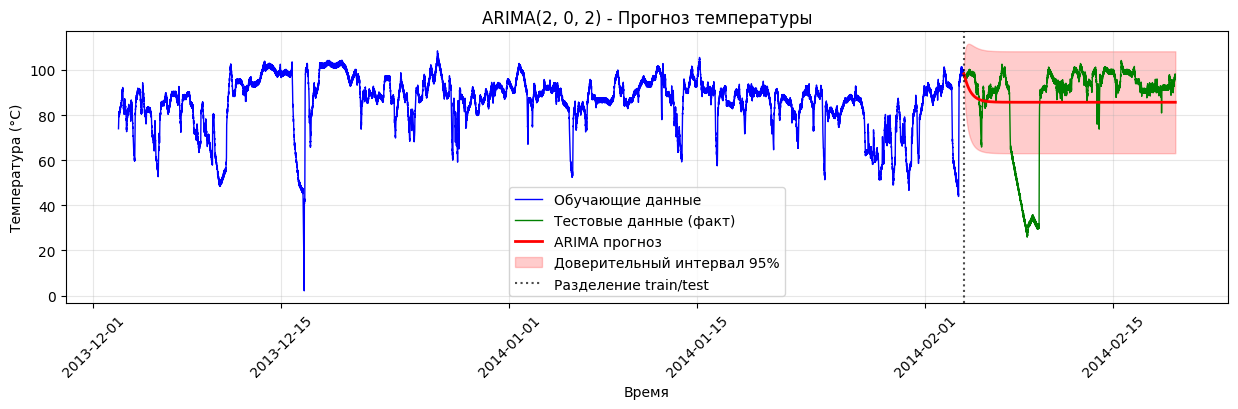

In [ ]:
plt.figure(figsize=(15, 12))

plt.subplot(3, 1, 1)
plt.plot(train_data['timestamp'], train_data['value'], label='Обучающие данные', color='blue', linewidth=1)
plt.plot(test_data_arima['timestamp'], test_data_arima['value'], label='Тестовые данные (факт)', color='green', linewidth=1)
plt.plot(test_data_arima['timestamp'], test_data_arima['arima_prediction'], label='ARIMA прогноз', color='red', linewidth=2)
plt.fill_between(test_data_arima['timestamp'],
                test_data_arima['arima_lower'],
                test_data_arima['arima_upper'],
                color='red', alpha=0.2, label='Доверительный интервал 95%')
plt.axvline(x=train_data['timestamp'].iloc[-1], color='black', linestyle=':', alpha=0.7, label='Разделение train/test')
plt.title(f'ARIMA{best_params} - Прогноз температуры')
plt.xlabel('Время')
plt.ylabel('Температура (°C)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

### Замеры качества модели

In [ ]:
arima_metrics = calculate_metrics(test_data_arima['value'], test_data_arima['arima_prediction'])

print("\n ARIMA ПРОГНОЗ:")
for metric, value in arima_metrics.items():
    if metric == 'MAPE':
        print(f"   {metric}: {value}%")
    else:
        print(f"   {metric}: {value}°C")


 ARIMA ПРОГНОЗ:
   MAE: 13.4618°C


## Классическая модель

### Импорт модулей

In [ ]:
from sklearn.ensemble import RandomForestRegressor

### Использование Feature-Engineering для создания признаков

In [ ]:

def create_features(df, target_col='value', max_lags=24, window_sizes=[6, 12, 24]):

    df_feat = df.copy()
    # Признаки даты и времени
    df_feat['hour'] = df_feat['timestamp'].dt.hour
    df_feat['dayofweek'] = df_feat['timestamp'].dt.dayofweek
    df_feat['dayofyear'] = df_feat['timestamp'].dt.dayofyear
    df_feat['weekofyear'] = df_feat['timestamp'].dt.isocalendar().week
    df_feat['month'] = df_feat['timestamp'].dt.month
    df_feat['quarter'] = df_feat['timestamp'].dt.quarter
    df_feat['is_weekend'] = (df_feat['timestamp'].dt.dayofweek >= 5).astype(int)
    # Циклические признаки для часа
    df_feat['hour_sin'] = np.sin(2 * np.pi * df_feat['hour'] / 24)
    df_feat['hour_cos'] = np.cos(2 * np.pi * df_feat['hour'] / 24)
    # Циклические признаки для дня недели
    df_feat['dayofweek_sin'] = np.sin(2 * np.pi * df_feat['dayofweek'] / 7)
    df_feat['dayofweek_cos'] = np.cos(2 * np.pi * df_feat['dayofweek'] / 7)

    # Лаги
    for lag in range(1, max_lags + 1):
        df_feat[f'lag_{lag}'] = df_feat[target_col].shift(lag)

    # Скользящие статистики
    for window in window_sizes:
        df_feat[f'rolling_mean_{window}'] = df_feat[target_col].rolling(window=window, min_periods=1).mean()
        df_feat[f'rolling_std_{window}'] = df_feat[target_col].rolling(window=window, min_periods=1).std()
        df_feat[f'rolling_min_{window}'] = df_feat[target_col].rolling(window=window, min_periods=1).min()
        df_feat[f'rolling_max_{window}'] = df_feat[target_col].rolling(window=window, min_periods=1).max()
        df_feat[f'rolling_median_{window}'] = df_feat[target_col].rolling(window=window, min_periods=1).median()

        # Процентные изменения
        df_feat[f'pct_change_{window}'] = df_feat[target_col].pct_change(periods=window)

    # Разности
    df_feat['diff_1'] = df_feat[target_col].diff(1)
    df_feat['diff_24'] = df_feat[target_col].diff(24)

    # Сезонные разности
    df_feat['seasonal_diff_24'] = df_feat[target_col] - df_feat[target_col].shift(24)

    # Экспоненциальное сглаживание
    df_feat['ewm_alpha_0.3'] = df_feat[target_col].ewm(alpha=0.3).mean()
    df_feat['ewm_alpha_0.7'] = df_feat[target_col].ewm(alpha=0.7).mean()

    # Время от начала наблюдений
    df_feat['time_index'] = range(len(df_feat))

    return df_feat

# Создаем признаки
df_features = create_features(df, 'value', max_lags=24, window_sizes=[6, 12, 24, 48])

print(f"Исходное количество признаков: 1 (value)")
print(f"Количество созданных признаков: {len(df_features.columns) - 2}")
print(f"Общее количество признаков: {len(df_features.columns)}")
print(df_features.columns.tolist()[:20])  # Покажем первые 20 признаков

Исходное количество признаков: 1 (value)
Количество созданных признаков: 65
Общее количество признаков: 67
['timestamp', 'value', 'hour', 'dayofweek', 'dayofyear', 'weekofyear', 'month', 'quarter', 'is_weekend', 'hour_sin', 'hour_cos', 'dayofweek_sin', 'dayofweek_cos', 'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6', 'lag_7']


In [ ]:
df_features_clean = df_features.dropna().reset_index(drop=True)

print(f"Размер датасета после очистки: {len(df_features_clean)}")
print(f"Количество признаков: {len(df_features_clean.columns) - 2}")

# Разделяем на признаки и целевую переменную
X = df_features_clean.drop(['timestamp', 'value'], axis=1)
y = df_features_clean['value']

print(f"Форма X: {X.shape}")
print(f"Форма y: {y.shape}")

Размер датасета после очистки: 22647
Количество признаков: 65
Форма X: (22647, 65)
Форма y: (22647,)


In [ ]:
# Разделение на train/test с учетом временного порядка
train_size = int(len(X) * 0.8)
X_train = X.iloc[:train_size]
X_test = X.iloc[train_size:]
y_train = y.iloc[:train_size]
y_test = y.iloc[train_size:]

print(f"Обучающая выборка: {X_train.shape}")
print(f"Тестовая выборка: {X_test.shape}")

Обучающая выборка: (18117, 65)
Тестовая выборка: (4530, 65)


### Обучение случайного леса

In [ ]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Модель обучена!")

Модель обучена!


### Пронозирование и оценка качества

In [ ]:
# Прогнозирование на тестовой выборке
y_pred_rf = rf_model.predict(X_test)

results_rf = pd.DataFrame({
    'timestamp': df_features_clean['timestamp'].iloc[train_size:train_size + len(y_test)],
    'actual': y_test.values,
    'rf_prediction': y_pred_rf
})

results_rf = results_rf.merge(test_data_arima[['timestamp', 'arima_prediction', 'naive_prediction']],
                             on='timestamp', how='left')

### Визуализация результата работы модели

(array([16040., 16054., 16071., 16085., 16102., 16116.]),
 [Text(16040.0, 0, '2013-12-01'),
  Text(16054.0, 0, '2013-12-15'),
  Text(16071.0, 0, '2014-01-01'),
  Text(16085.0, 0, '2014-01-15'),
  Text(16102.0, 0, '2014-02-01'),
  Text(16116.0, 0, '2014-02-15')])

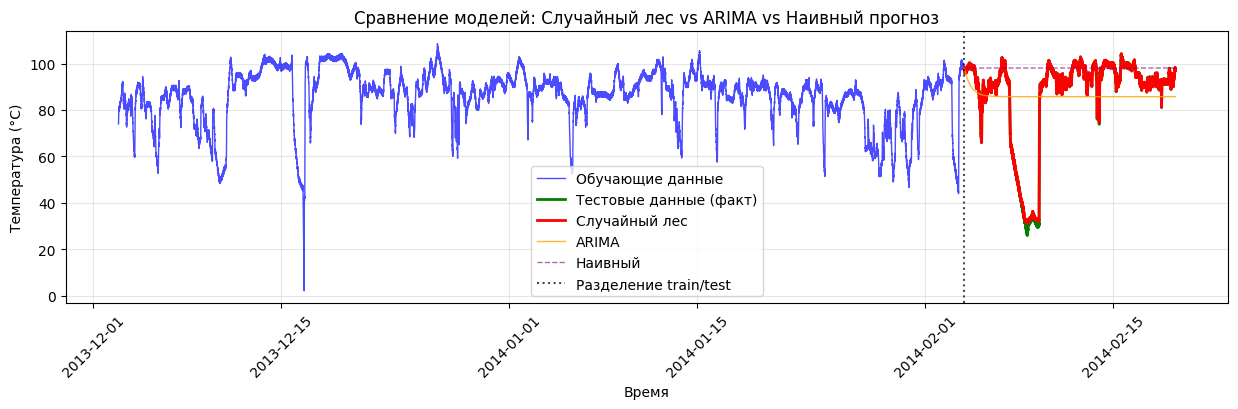

In [ ]:
plt.figure(figsize=(15, 12))

plt.subplot(3, 1, 1)
plt.plot(train_data['timestamp'], train_data['value'], label='Обучающие данные', color='blue', linewidth=1, alpha=0.7)
plt.plot(results_rf['timestamp'], results_rf['actual'], label='Тестовые данные (факт)', color='green', linewidth=2)
plt.plot(results_rf['timestamp'], results_rf['rf_prediction'], label='Случайный лес', color='red', linewidth=2)
plt.plot(results_rf['timestamp'], results_rf['arima_prediction'], label='ARIMA', color='orange', linewidth=1, alpha=0.8)
plt.plot(results_rf['timestamp'], results_rf['naive_prediction'], label='Наивный', color='purple', linewidth=1, alpha=0.6, linestyle='--')
plt.axvline(x=train_data['timestamp'].iloc[-1], color='black', linestyle=':', alpha=0.7, label='Разделение train/test')
plt.title('Сравнение моделей: Случайный лес vs ARIMA vs Наивный прогноз')
plt.xlabel('Время')
plt.ylabel('Температура (°C)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

### Замеры качества модели

In [ ]:
def calculate_detailed_metrics(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    max_error = np.max(np.abs(y_true - y_pred))
    std_error = np.std(y_true - y_pred)

    return {
        'Model': model_name,
        'MAE': round(mae, 4),
        'Max Error': round(max_error, 4),
        'Std Error': round(std_error, 4)
    }

metrics_rf = calculate_detailed_metrics(results_rf['actual'], results_rf['rf_prediction'], 'Random Forest')


comparison_df = pd.DataFrame([metrics_rf])
print(comparison_df.to_string(index=False))

        Model    MAE  Max Error  Std Error
Random Forest 0.1684      5.393     0.5217


## PEP8

In [ ]:
!pip install black[jupyter] --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.5/83.5 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 25.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 81.0 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
!black /content/drive/MyDrive/Colab Notebooks/HomeWork2.ipynb